In [ ]:
%pip install bayesian-optimization

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
def black_box_function(x, y):
    return -((x - 2)**2 + (y - 3)**2) # Example: maximizing negative of a squared error

In [3]:
pbounds = {'x': (0, 5), 'y': (0, 5)}

In [4]:
from bayes_opt import BayesianOptimization

optimizer = BayesianOptimization(
    f=black_box_function,
    pbounds=pbounds,
    random_state=1,
)

In [5]:
optimizer.maximize(
        init_points=5,
        n_iter=20,
)

|   iter    |  target   |     x     |     y     |
-------------------------------------------------
| 1         | -0.369193 | 2.0851100 | 3.6016224 |
| 2         | -6.212860 | 0.0005718 | 1.5116628 |
| 3         | -8.046317 | 0.7337794 | 0.4616929 |
| 4         | -2.760601 | 0.9313010 | 1.7278036 |
| 5         | -0.093846 | 1.9838373 | 2.6940836 |


| 6         | -5.176903 | 4.2751272 | 3.0264470 |
| 7         | -2.531470 | 0.6149843 | 3.7830724 |
| 8         | -4.264726 | 2.5145156 | 5.0       |
| 9         | -2.472808 | 2.7163893 | 1.6001448 |
| 10        | -18.0     | 5.0       | 0.0       |
| 11        | -13.0     | 5.0       | 5.0       |
| 12        | -8.0      | 0.0       | 5.0       |
| 13        | -0.775082 | 2.8803801 | 2.9963344 |
| 14        | -0.576336 | 1.2430509 | 2.9419967 |
| 15        | -0.034033 | 1.8904362 | 3.1484235 |
| 16        | -0.072937 | 2.2640725 | 3.0566009 |
| 17        | -0.352837 | 2.4183147 | 2.5782773 |
| 18        | -0.001543 | 2.0065849 | 2.9612687 |
| 19        | -0.031603 | 1.8343948 | 2.9353566 |
| 20        | -0.009154 | 2.0377998 | 3.0878956 |
| 21        | -0.000223 | 2.0071843 | 2.9868892 |
| 22        | -0.000345 | 1.9828153 | 3.0070563 |
| 23        | -0.003855 | 2.0495214 | 2.9625421 |
| 24        | -0.000497 | 1.9804632 | 3.0107601 |
| 25        | -0.000319 | 1.9847895 | 3.0093632 |


In [6]:
print(optimizer.max)

{'target': -0.0002235081970246011, 'params': {'x': 2.0071843670731284, 'y': 2.9868892003759058}}


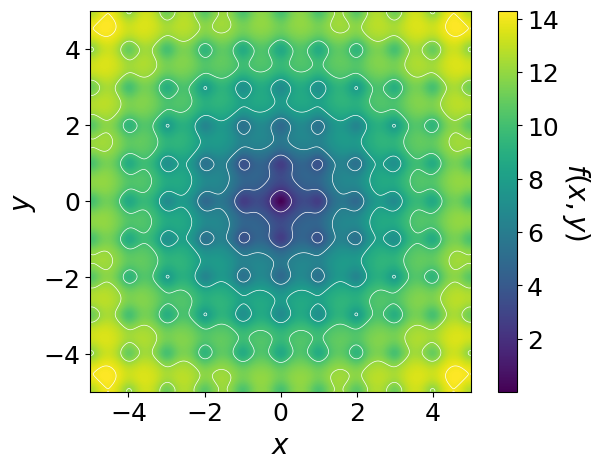

In [7]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib
#matplotlib.rcParams['text.usetex'] = True
x_linspace,y_linspace = np.meshgrid(np.linspace(-5,5,1500),np.linspace(-5,5,1500))
ackley = -20. * np.exp(-0.2 * np.sqrt(0.5 * (x_linspace**2 + y_linspace**2))) - np.exp(0.5 * (np.cos(2 * np.pi * x_linspace) + np.cos(2 * np.pi * y_linspace))) + np.e + 20
plt.pcolormesh(x_linspace, y_linspace, ackley)
plt.xlabel(r"$x$", fontsize=20)
plt.ylabel(r"$y$", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
cbar = plt.colorbar(ticks=np.linspace(0,14,8))
cbar.ax.tick_params(labelsize=18)
cbar.set_label(r"$f\left(x,y\right)$", fontsize=20, rotation=-90, labelpad=24)
contour_lines = plt.contour(x_linspace, y_linspace, ackley, colors='w', levels=np.linspace(2,14,7), linewidths=0.5)
plt.gca().set_aspect(1)
plt.tight_layout()
plt.savefig('ackley_2d.png', dpi=500, bbox_inches='tight')
plt.show()

# Suggest-Evaluate-Register Paradigm

In [8]:
from bayes_opt import BayesianOptimization

# Let's start by defining our function, bounds, and instantiating an optimization object.
def black_box_function(x, y):
    print('nyeh!')
    return -((x - 2)**2 + (y - 3)**2)

from bayes_opt import acquisition

acq = acquisition.UpperConfidenceBound(kappa=4)

optimizer = BayesianOptimization(
    f=None,
    acquisition_function=acq,
    pbounds={'x': (0, 5), 'y': (0, 5)},
    verbose=2,
    random_state=1,
    allow_duplicate_points=True
)

for _ in range(20):
    next_point = optimizer.suggest()
    target = black_box_function(**next_point)
    optimizer.register(params=next_point, target=target)

    print(target, next_point)
print(optimizer.max)

nyeh!
| 1         | -0.369193 | 2.0851100 | 3.6016224 |
-0.36919330915515985 {'x': 2.08511002351287, 'y': 3.6016224672107904}
nyeh!
| 2         | -17.35377 | 4.9735527 | 0.0825079 |
-17.35377614527745 {'x': 4.973552799433601, 'y': 0.0825079444396002}
nyeh!
| 3         | -0.413348 | 1.9282041 | 3.6389004 |
-0.4133483637474599 {'x': 1.9282041764822675, 'y': 3.6389004018412185}
nyeh!
| 4         | -13.0     | 0.0       | 0.0       |
-13.0 {'x': 0.0, 'y': 0.0}
nyeh!
| 5         | -13.0     | 5.0       | 5.0       |
-13.0 {'x': 5.0, 'y': 5.0}
nyeh!
| 6         | -8.0      | 0.0       | 5.0       |
-8.0 {'x': 0.0, 'y': 5.0}
nyeh!
| 7         | -1.169653 | 1.8822229 | 1.9249269 |
-1.1696534087311572 {'x': 1.8822229184343215, 'y': 1.9249269942050313}
nyeh!
| 8         | -4.137599 | 0.0       | 2.6290563 |
-4.137599158857783 {'x': 0.0, 'y': 2.6290563939656284}
nyeh!
| 9         | -4.167900 | 2.4097564 | 5.0       |
-4.1679003113913335 {'x': 2.4097564049424167, 'y': 5.0}
nyeh!
| 10        | -2.6

In [9]:
from bayes_opt import BayesianOptimization, acquisition

Text(0.97, 0.97, '$\\nu$ = 8720 MHz')

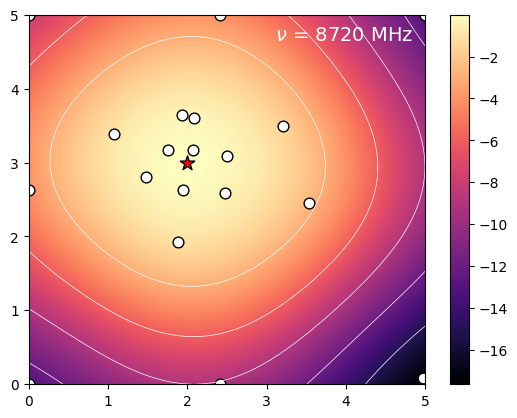

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
pbounds = {'x': (0, 5), 'y': (0, 5)}
x = np.linspace(pbounds['x'][0], pbounds['x'][1], 1000)
y = np.linspace(pbounds['y'][0], pbounds['y'][1], 1000)
xy = np.array([[x_i, y_j] for y_j in y for x_i in x])
X, Y = np.meshgrid(x, y)

Z_est = optimizer._gp.predict(xy).reshape(X.shape)

fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y, Z_est, cmap=mpl.colormaps['magma'])
fig.colorbar(im)
ax.contour(X, Y, Z_est, levels=5, colors='w', linewidths=0.5, linestyles='-')

max_ = optimizer.max
res = optimizer.res
max_x, max_y = max_["params"]['x'], max_["params"]['y']
x_ = np.array([r["params"]['x'] for r in res if r["params"]['x'] != max_x])
y_ = np.array([r["params"]['y'] for r in res if r["params"]['y'] != max_y])

ax.scatter(x_, y_, c='white', s=60, edgecolors='black')
ax.scatter(max_x, max_y, c='red', s=120, marker='*', edgecolors='black')

ax.text(0.97, 0.97, '$\\nu$ = 8720 MHz', transform=ax.transAxes, ha='right', va='top', fontsize=14, color='white')

In [40]:
optimizer.save_state("optimizer_state.json")

In [2]:
acq = acquisition.UpperConfidenceBound(kappa=4)
optimizer = BayesianOptimization(
    f=None,
    acquisition_function=acq,
    pbounds={'x': (0, 5), 'y': (0, 5)},
    verbose=2,
    random_state=1,
    allow_duplicate_points=True
)

optimizer.load_state("optimizer_state.json")

| 1         | -0.369193 | 2.0851100 | 3.6016224 |
| 2         | -17.35377 | 4.9735527 | 0.0825079 |
| 3         | -0.274837 | 1.9452166 | 3.5213794 |
| 4         | -8.0      | 0.0       | 5.0       |
| 5         | -13.0     | 0.0       | 0.0       |
| 6         | -13.0     | 5.0       | 5.0       |
| 7         | -1.490260 | 2.6061986 | 1.9403849 |
| 8         | -4.214132 | 0.0       | 2.5372554 |
| 9         | -4.248835 | 4.0523195 | 2.8081152 |
| 10        | -4.007557 | 2.0869355 | 5.0       |
| 11        | -1.182654 | 1.3925875 | 2.0979440 |
| 12        | -0.270648 | 2.4895865 | 2.8240632 |
| 13        | -1.130320 | 0.9572505 | 3.2073513 |
| 14        | -0.128796 | 1.7633079 | 2.7302341 |
| 15        | -1.425179 | 3.0563423 | 3.5561661 |
| 16        | -0.027486 | 2.1115736 | 3.1226270 |
| 17        | -0.290550 | 2.0909053 | 2.4686931 |
| 18        | -0.084174 | 1.7265802 | 3.0970356 |
| 19        | -0.009607 | 2.0229110 | 2.9046956 |
| 20        | -0.005371 | 1.9453853 | 3.0488771 |


/home/bhanselman/anaconda3/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:629: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


# Real Bayesian Optimization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bayes_opt import BayesianOptimization, acquisition
import os

from matplotlib.colors import Normalize

In [9]:
optimize_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/snr_evals/bayes_final_decay_2/0'
files = [file for file in os.listdir(optimize_dir) if file.endswith('.json')]
files

['optimized_7900.json',
 'optimized_8100.json',
 'optimized_8300.json',
 'optimized_8500.json',
 'optimized_8700.json']

In [10]:
files = [
    'optimized_7900.json',
    'optimized_8100.json',
    'optimized_8300.json'
]

{'target': 6.8588430120982125, 'params': {'a': 0.4988466581598726, 'exterior': 0.6341248465642177}}
1.4988466581598727 6.8047490793853065
{'target': 22.143720398802323, 'params': {'a': 0.8026316450236064, 'exterior': 0.9484196205531464}}
1.8026316450236064 8.690517723318878
{'target': 53.32054475988518, 'params': {'a': 0.6357886063137365, 'exterior': 0.9415893695834238}}
1.6357886063137363 8.649536217500543


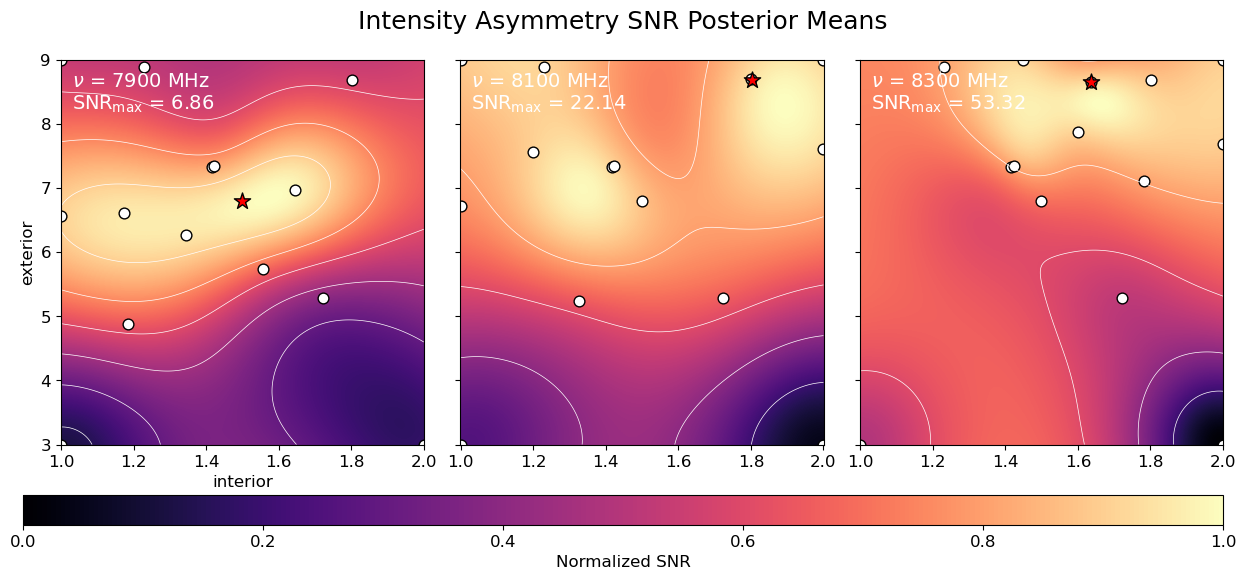

In [13]:
acq = acquisition.UpperConfidenceBound(kappa=2)

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.titlesize': 18})

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(15,5))
fig.subplots_adjust(hspace=0, wspace=0.1)

norm = Normalize(vmin=0, vmax=1)

def normalize_number(value, desired_min, desired_max, original_min=0, original_max=1):
    return(value - original_min) * (desired_max - desired_min) / (original_max - original_min) + desired_min

axs[0].set_xlabel('interior')
axs[0].set_ylabel('exterior')

for file, ax in zip(files, axs.flat):
    pbounds = {'a': (0, 1), 'exterior': (0, 1)} #{'nsigma': (0.5, 2.5), 'window': (131, 301, int)}
    optimizer = BayesianOptimization(
        f=None,
        acquisition_function=acq,
        pbounds=pbounds,
        verbose=0,
        random_state=1,
        allow_duplicate_points=True
    )
    optimizer.load_state(os.path.join(optimize_dir, file))
    
    x = np.linspace(pbounds['a'][0], pbounds['a'][1], 1000)
    y = np.linspace(pbounds['exterior'][0], pbounds['exterior'][1], 1000)
    xy = np.array([[x_i, y_j] for y_j in y for x_i in x])
    plot_x = np.linspace(1, 2, 1000)
    plot_y = np.linspace(3, 9, 1000) #131, 301
    X, Y = np.meshgrid(plot_x, plot_y)

    #print(f'plot_x, plot_y: {plot_x, plot_y}. xy: {xy}.')
    Z_est = optimizer._gp.predict(xy).reshape(X.shape)
    Z_est = Z_est / np.max(Z_est)

    im = ax.pcolormesh(X, Y, Z_est, norm=norm, cmap=mpl.colormaps['magma'])
    # if ax == axs.flat[0]:
    #     ax.set_xlabel('$n\sigma$') #a$
    #     ax.set_ylabel('window factor (MHz$^{-1}$)')
    # else:
    #     ax.tick_params(axis='x', labelbottom=False)
        
    ax.contour(X, Y, Z_est, levels=5, colors='w', linewidths=0.5, linestyles='-')
    
    max_ = optimizer.max
    print(max_)
    res = optimizer.res
    max_x, max_y = normalize_number(max_["params"]['a'], 1, 2), normalize_number(max_["params"]['exterior'], 3, 9) #131, 301
    print(max_x, max_y)
    x_ = normalize_number(np.array([r["params"]['a'] for r in res]), 1, 2)
    y_ = normalize_number(np.array([r["params"]['exterior'] for r in res]), 3, 9) #131, 301
    x_, y_ = list(zip(*[(x_i, y_j) for x_i, y_j in zip(x_, y_) if x_i != max_x or y_j != max_y]))
    #print(list(zip(x_,y_)))
    
    ax.scatter(x_, y_, c='white', s=60, edgecolors='black')
    ax.scatter(max_x, max_y, c='red', s=150, marker='*', edgecolors='black')
    
    freq = file.split('_')[-1].split('.')[0]
    text = f'$\\nu$ = {freq} MHz' #f'order = {file.split("_")[1]}'
    ax.text(0.03, 0.97, f'{text}\n$\mathrm{{SNR}}_\mathrm{{max}}$ = {round(max_["target"], 2)}',
            transform=ax.transAxes, ha='left', va='top', fontsize=14, color='w')

cax = fig.add_axes([0.1, -0.05, 0.8, 0.06])
cbar = fig.colorbar(im, cax=cax, norm=norm, cmap='magma',
             label='Normalized SNR', orientation='horizontal')

fig.suptitle('Intensity Asymmetry SNR Posterior Means') #($\lambda=10^{-28} \mathrm{s}^{-1}$)
plt.savefig('../images/bayes_presentation.png', dpi=500, bbox_inches='tight')

Data point [1. 1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1. 1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1. 1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1. 1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1. 1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1. 1.] is not unique. 6 duplicates registered. Continuing ...


/home/bhanselman/anaconda3/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:629: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


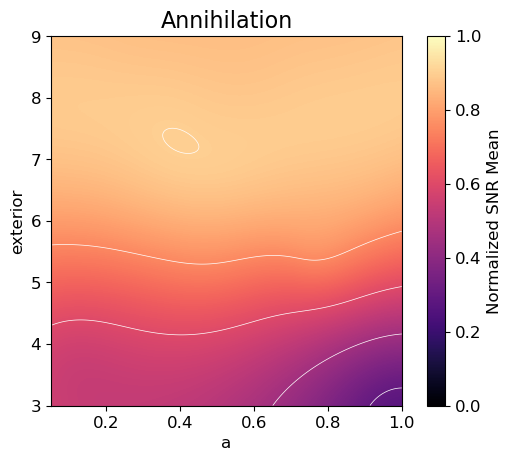

In [13]:
x = np.linspace(0, 1, 1000)
y = np.linspace(0, 1, 1000)
xy = np.array([[x_i, y_j] for y_j in y for x_i in x])
plot_x = np.linspace(0.05, 1, 1000)
plot_y = np.linspace(3, 9, 1000) #131, 301
X, Y = np.meshgrid(plot_x, plot_y)

norm = Normalize(vmin=0, vmax=1)

def get_Z_norm(file):
    pbounds = {'a': (0, 1), 'exterior': (0, 1)} #{'nsigma': (0.5, 2.5), 'window': (131, 301, int)}
    optimizer = BayesianOptimization(
        f=None,
        acquisition_function=acq,
        pbounds=pbounds,
        verbose=0,
        random_state=1,
        allow_duplicate_points=True
    )
    optimizer.load_state(os.path.join(optimize_dir, file))
    
    Z_est = optimizer._gp.predict(xy).reshape(X.shape)
    Z_est = Z_est / np.max(Z_est)
    return Z_est

Z_mean = np.mean([get_Z_norm(file) for file in files], axis=0)

plt.pcolormesh(X, Y, Z_mean, norm=norm, cmap=mpl.colormaps['magma'])
plt.colorbar(label='Normalized SNR Mean', cmap='magma', norm=norm)
plt.contour(X, Y, Z_mean, levels=5, colors='w', linewidths=0.5, linestyles='-')
plt.xlabel('a')
plt.ylabel('exterior')
plt.gca().set_aspect(1/6)
plt.title('Annihilation')
plt.savefig('../images/bayes_weighted_ann_avg.png', dpi=500, bbox_inches='tight')

In [6]:
list(zip(x_, y_))

[(0.834044009405148, 0.029406489868843165),
 (1.9986183139086242, 0.015008437827648814),
 (1.9892086440292334, 0.015065898771385646),
 (1.9986487149546208, 0.01520127223780988),
 (1.6052632900472128, 0.033968392411062934),
 (0.9976933163197452, 0.027682496931284356),
 (1.5934487487173081, 0.029388477759505545),
 (1.4441785879746187, 0.022617139932165766),
 (1.0477864783428736, 0.03479958982456108),
 (1.9752971926901697, 0.015122952699588185),
 (1.2483406371920023, 0.027615550535071448),
 (0.19404579517683174, 0.01772230825468478),
 (0.17536554326964393, 0.022045118347515928),
 (1.4467375947712033, 0.019451673386386523),
 (0.7086064034313166, 0.034424895628646035),
 (0.712144954603144, 0.02292731845505396),
 (0.7805917415363333, 0.025766609192588556)]

In [28]:
x_ == max_x

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False])

In [32]:
list(zip(*[(x_i, y_j) for x_i, y_j in zip(x_, y_) if x_i != max_x and y_j != max_y]))

[(0.834044009405148,
  2.0,
  0.8454876454753406,
  1.099859626722001,
  1.4616105568393563,
  0.4601546805355876,
  1.6052632900472128,
  2.0,
  0.9976933163197452,
  0.0,
  1.4441785879746187,
  2.0,
  1.6051053930428583,
  2.0,
  1.0317134358526099,
  0.0,
  1.1393234910298344,
  1.4187308532977299,
  1.7366503642366562,
  0.0,
  0.0,
  1.7783514515030452,
  1.6051436855383219,
  0.7972320176510871),
 (253.45516388516688,
  131.0,
  254.21159237577737,
  271.0258157301372,
  241.50137731910092,
  297.7213394661259,
  292.23133549403485,
  268.58320799588193,
  238.80122391591703,
  131.0,
  195.74568942340898,
  301.0,
  291.91858089900916,
  215.84810851299278,
  301.0,
  266.7783126186854,
  131.0,
  267.9492636405375,
  264.72035180440866,
  205.61552697561132,
  301.0,
  301.0,
  291.993852487611,
  280.4602780938749)]

# Plotting maxima

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bayes_opt import BayesianOptimization, acquisition
import os
from matplotlib.colors import Normalize

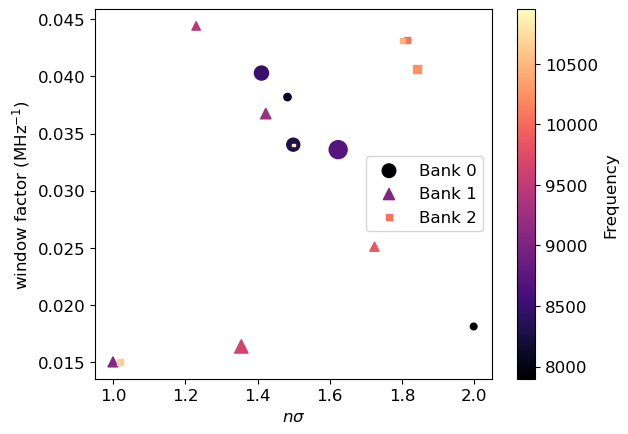

In [11]:
acq = acquisition.UpperConfidenceBound(kappa=2)

fig, ax = plt.subplots()

def normalize_number(value, desired_min, desired_max, original_min=0, original_max=1):
    return(value - original_min) * (desired_max - desired_min) / (original_max - original_min) + desired_min

norm = Normalize(vmin=7900, vmax=10950)

banks = ['0', '1', '2']
markers = ['o', '^', 's']

for bank, marker in zip(banks, markers):
    optimize_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/snr_evals/bayes_multi_signal_annihilation/{bank}/'
    files = [file for file in os.listdir(optimize_dir) if file.endswith('.json')]
    
    xs = []
    ys = []
    
    sizes = []
    
    for file in files:
        pbounds = {'nsigma': (0, 1), 'window_factor': (0, 1)} #{'nsigma': (0.5, 2.5), 'window': (131, 301, int)}
        optimizer = BayesianOptimization(
            f=None,
            acquisition_function=acq,
            pbounds=pbounds,
            verbose=0,
            random_state=1,
            allow_duplicate_points=True
        )
        optimizer.load_state(os.path.join(optimize_dir, file))

        max_ = optimizer.max
        max_x, max_y = normalize_number(max_["params"]['nsigma'], 1, 2), normalize_number(max_["params"]['window_factor'], 3, 9) #131, 301
        s = max_['target']
        
        xs.append(max_x)
        ys.append(max_y)
        sizes.append(s)

    freqs = [int(file.split('_')[-1].split('.')[0]) for file in files]
    scatter = ax.scatter(xs, ys, c=freqs, s=sizes, marker=marker, cmap='magma', norm=norm, label=f'Bank {bank}')
    
    
cbar = fig.colorbar(scatter, ax=ax, cmap='magma', label='Frequency', orientation='vertical')

#ax.set_xlim(1, 2)
#ax.set_ylim(0.015, 0.040)
ax.set_xlabel('$n\sigma$') #a$
ax.set_ylabel('window factor (MHz$^{-1}$)')
ax.legend()

plt.savefig('/home/bhanselman/images/bayes_multi_signal_annihilation_scatter.png', dpi=500)

In [14]:
from zipfile import ZipFile
path_to_save = '/home/bhanselman/asymmetry_plots/snr_evals/bayes_multi_signal_final/'
with ZipFile('/home/bhanselman/bayes_multi_signal_final.zip', 'w') as zipf:
    for bank in os.listdir(path_to_save):
        for freq in os.listdir(os.path.join(path_to_save, bank)):
                for file in os.listdir(os.path.join(path_to_save, bank, freq))
                    name = os.path.join(path_to_save, bank, freq, file)
                    arcname = os.path.join(bank, freq, file)
                    zipf.write(name, arcname=arcname)


# Modified asymmetries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bayes_opt import BayesianOptimization, acquisition
import os
from matplotlib.colors import Normalize

In [10]:
optimize_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/snr_evals/bayes_weighted_modified_decay'
files = {order : [file for file in os.listdir(os.path.join(optimize_dir, order)) if file.endswith('.json')] for order in os.listdir(optimize_dir)}
files

{'order_3': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json',
  'optimized_9450.json',
  'optimized_9550.json',
  'optimized_9650.json',
  'optimized_9750.json',
  'optimized_9850.json',
  'optimized_9950.json',
  'optimized_10050.json'],
 'order_4': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json',
  'optimized_9450.json',
  'optimized_9550.json',
  'optimized_9650.json',
  'optimized_9750.json',
  'optimized_9850.json',
  'optimized_9950.json',
  'optimized_10050.json'],
 'order_5': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json',
  'optimized_9450.json',
  'optimized_9550.json',
  'optimized_9650.json',
  'optimized_9750.json',
  'optimized_9850.json',
  'optimized_9950.json',
  'optimized_10050.json'],
 'order_6': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json',
  'optimized_9450.json',


Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1.] is not unique. 6 duplicates registered. Continuing ...
Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1.] is not unique. 6 duplicates registered. Continuing ...
Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data p

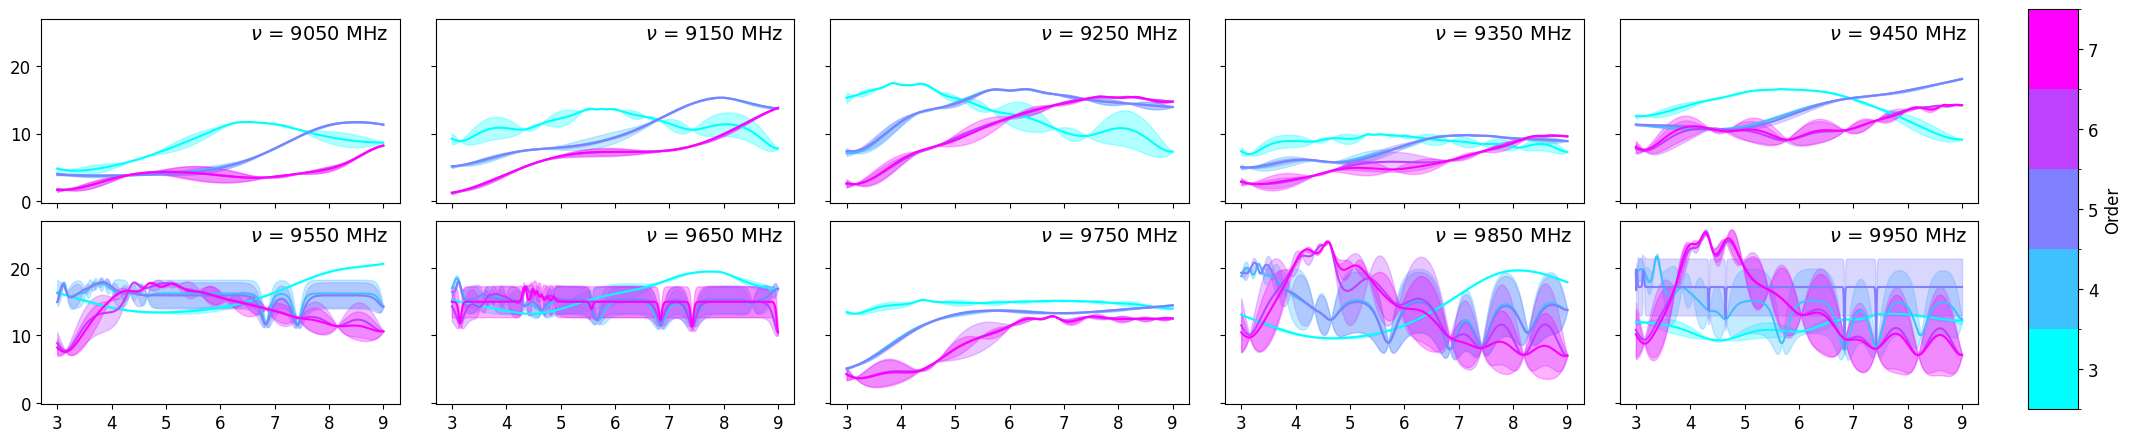

In [22]:
import warnings
warnings.filterwarnings("ignore")

acq = acquisition.UpperConfidenceBound(kappa=2)

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.titlesize': 18})

fig, axs = plt.subplots(2, 5, sharex=True, sharey=True, figsize=(25,5))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

norm = Normalize(vmin=0, vmax=1)

def normalize_number(value, desired_min, desired_max, original_min=0, original_max=1):
    return(value - original_min) * (desired_max - desired_min) / (original_max - original_min) + desired_min

cmap = mpl.colormaps['cool']
colors = [cmap(i) for i in np.linspace(0, 1, len(files.keys()))]

for order, color in zip(files.keys(), colors):
    for file, ax in zip(files[order], axs.flat):
        pbounds = {'exterior': (0, 1)}
        optimizer = BayesianOptimization(
            f=None,
            acquisition_function=acq,
            pbounds=pbounds,
            verbose=0,
            random_state=1,
            allow_duplicate_points=True
        )
        optimizer.load_state(os.path.join(optimize_dir, order, file))
        
        x = np.linspace(0, 1, 1000)
        plot_x = np.linspace(3, 9, 1000)
        y_mean, y_std = optimizer._gp.predict(x.reshape(-1, 1), return_std=True)
        ax.plot(plot_x, y_mean, color=color)
        ax.fill_between(plot_x, y_mean - y_std, y_mean + y_std, alpha=0.3, color=color)
        
cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
import matplotlib.colors as mcolors

bounds = np.arange(len(files.keys())+1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
discrete_cmap = mcolors.ListedColormap(colors)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['cool']), cax=cax, label='Order', ticks=[b + 0.5 for b in bounds[:-1]]) # Ticks in the middle of intervals
cbar.set_ticklabels([str(int(b) + 3) for b in bounds[:-1]]) # Label ticks with category values

# norm = mcolors.Normalize(vmin=0, vmax=len(files.keys())-1)
# cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['winter']),
#                     cax=cax, label='Order', ticks=range(len(files.keys())))
# cbar.ax.set_yticklabels(list(files.keys()))

freqs = [file.split('_')[-1].split('.')[0] for file in files[order]]
for ax, freq in zip(axs.flat, freqs):
    ax.text(0.97, 0.97, f'$\\nu$ = {freq} MHz',
            transform=ax.transAxes, ha='right', va='top', fontsize=14, color='black')

## AAS plot

In [2]:
optimize_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/snr_evals/bayes_weighted_modified_decay'
files = {order : [file for file in os.listdir(os.path.join(optimize_dir, order)) if file.endswith('.json') and int(file.split('.')[0].split('_')[1]) < 9400] for order in os.listdir(optimize_dir)}
files

{'order_3': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json'],
 'order_4': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json'],
 'order_5': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json'],
 'order_6': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json'],
 'order_7': ['optimized_9050.json',
  'optimized_9150.json',
  'optimized_9250.json',
  'optimized_9350.json']}

Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1.] is not unique. 6 duplicates registered. Continuing ...
Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1.] is not unique. 6 duplicates registered. Continuing ...
Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data p

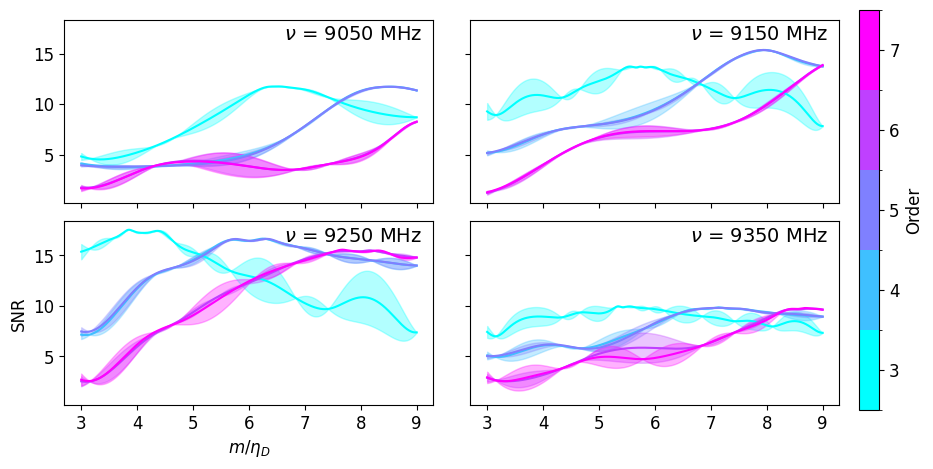

In [ ]:
import warnings
warnings.filterwarnings("ignore")

acq = acquisition.UpperConfidenceBound(kappa=2)

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.titlesize': 18})
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10,5))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

norm = Normalize(vmin=0, vmax=1)

def normalize_number(value, desired_min, desired_max, original_min=0, original_max=1):
    return(value - original_min) * (desired_max - desired_min) / (original_max - original_min) + desired_min

cmap = mpl.colormaps['cool']
colors = [cmap(i) for i in np.linspace(0, 1, len(files.keys()))]

for order, color in zip(files.keys(), colors):
    for file, ax in zip(files[order], axs.flat):
        pbounds = {'exterior': (0, 1)}
        optimizer = BayesianOptimization(
            f=None,
            acquisition_function=acq,
            pbounds=pbounds,
            verbose=0,
            random_state=1,
            allow_duplicate_points=True
        )
        optimizer.load_state(os.path.join(optimize_dir, order, file))
        
        x = np.linspace(0, 1, 1000)
        plot_x = np.linspace(3, 9, 1000)
        y_mean, y_std = optimizer._gp.predict(x.reshape(-1, 1), return_std=True)
        ax.plot(plot_x, y_mean, color=color)
        ax.fill_between(plot_x, y_mean - y_std, y_mean + y_std, alpha=0.3, color=color)

axs[1][0].set_xlabel(r'$m / \eta_D$', fontsize=16)
axs[1][0].set_ylabel('SNR', fontsize=16)

cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
import matplotlib.colors as mcolors

bounds = np.arange(len(files.keys())+1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
discrete_cmap = mcolors.ListedColormap(colors)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['cool']), cax=cax, label='Order', fontsize=16, ticks=[b + 0.5 for b in bounds[:-1]]) # Ticks in the middle of intervals
cbar.set_ticklabels([str(int(b) + 3) for b in bounds[:-1]]) # Label ticks with category values

# norm = mcolors.Normalize(vmin=0, vmax=len(files.keys())-1)
# cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['winter']),
#                     cax=cax, label='Order', ticks=range(len(files.keys())))
# cbar.ax.set_yticklabels(list(files.keys()))

freqs = [file.split('_')[-1].split('.')[0] for file in files[order]]
for ax, freq in zip(axs.flat, freqs):
    ax.text(0.97, 0.97, f'$\\nu$ = {freq} MHz',
            transform=ax.transAxes, ha='right', va='top', fontsize=14, color='black')

plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/optimization_aas.png', dpi=300, bbox_inches='tight')

Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1.] is not unique. 6 duplicates registered. Continuing ...
Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data point [1.] is not unique. 3 duplicates registered. Continuing ...
Data point [1.] is not unique. 4 duplicates registered. Continuing ...
Data point [1.] is not unique. 5 duplicates registered. Continuing ...
Data point [1.] is not unique. 6 duplicates registered. Continuing ...
Data point [1.] is not unique. 1 duplicates registered. Continuing ...
Data point [1.] is not unique. 2 duplicates registered. Continuing ...
Data p

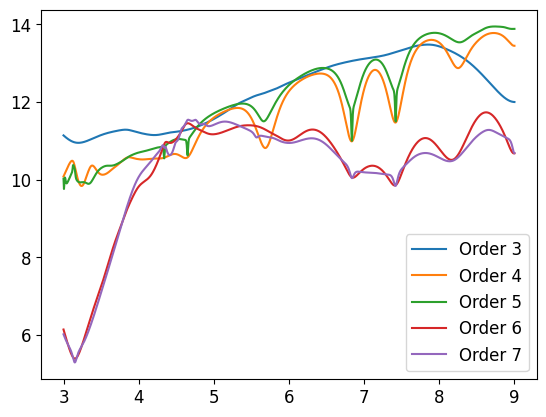

In [25]:
freqs = np.arange(9050, 10000, 100)
for order in files.keys():
    def get_y_mean(file):
        pbounds = {'exterior': (0, 1)}
        optimizer = BayesianOptimization(
            f=None,
            acquisition_function=acq,
            pbounds=pbounds,
            verbose=0,
            random_state=1,
            allow_duplicate_points=True
        )
        optimizer.load_state(os.path.join(optimize_dir, order, file))
        
        x = np.linspace(0, 1, 1000)
        y_mean = optimizer._gp.predict(x.reshape(-1, 1))
        return y_mean
    means = list(map(get_y_mean, files[order]))
    means_array = np.array(means)
    mean_of_means = np.mean(means_array, axis=0)

    plot_x = np.linspace(3, 9, 1000)
    plt.plot(plot_x, mean_of_means, label=f'Order {order[-1]}')

plt.legend()

# C-band testy westy

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bayes_opt import BayesianOptimization, acquisition
import os

from matplotlib.colors import Normalize

Text(0.03, 0.97, '$\\mathrm{SNR}_\\mathrm{max}$ = -0.0')

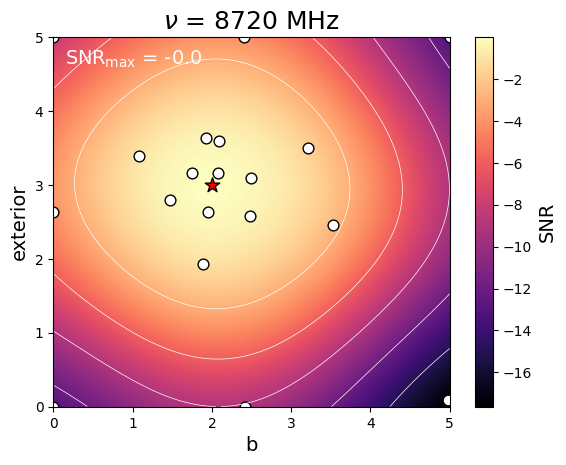

In [25]:
pbounds = {'x': (0, 5), 'y': (0, 5)}
x = np.linspace(pbounds['x'][0], pbounds['x'][1], 1000)
y = np.linspace(pbounds['y'][0], pbounds['y'][1], 1000)
xy = np.array([[x_i, y_j] for y_j in y for x_i in x])
X, Y = np.meshgrid(x, y)

Z_est = optimizer._gp.predict(xy).reshape(X.shape)

fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y, Z_est, cmap=mpl.colormaps['magma'])
cbar = fig.colorbar(im)
cbar.set_label('SNR', fontsize=14)
ax.contour(X, Y, Z_est, levels=5, colors='w', linewidths=0.5, linestyles='-')

max_ = optimizer.max
res = optimizer.res
max_x, max_y = max_["params"]['x'], max_["params"]['y']
x_, y_ = list(zip(*[(x_i, y_j) for x_i, y_j in zip(x_, y_) if x_i != max_x or y_j != max_y]))

ax.scatter(x_, y_, c='white', s=60, edgecolors='black')
ax.scatter(max_x, max_y, c='red', s=120, marker='*', edgecolors='black')

ax.set_xlabel('b', fontsize=14)
ax.set_ylabel('exterior', fontsize=14)
ax.set_title(f'$\\nu$ = {freq} MHz', fontsize=18) #f'order = {file.split("_")[1]}'
ax.text(0.03, 0.97, f'$\mathrm{{SNR}}_\mathrm{{max}}$ = {round(max_["target"], 2)}',
        transform=ax.transAxes, ha='left', va='top', fontsize=14, color='w')